<a href="https://colab.research.google.com/github/huyennt92/IBM-Data-Science-Capstone/blob/main/Course7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
import numpy as np

# 1. TẢI DỮ LIỆU GỐC VÀO BIẾN df (Đây chính là bước bạn đang thiếu)
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv"
df = pd.read_csv(file_url)

# 2. LÀM SẠCH DỮ LIỆU (Điền giá trị trung bình vào ô trống)
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].mean())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mean())

# 3. CHUẨN BỊ TẬP FEATURES VÀ CHIA TẬP TRAIN/TEST
features = ["floors", "waterfront", "lat", "bedrooms", "sqft_basement", "view", "bathrooms", "sqft_living15", "sqft_above", "grade", "sqft_living"]
X = df[features]
Y = df['price']

# Chia dữ liệu: 85% Train, 15% Test
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)

print("Tuyệt vời! Dữ liệu đã được tải, làm sạch và chia tập sẵn sàng!")

Tuyệt vời! Dữ liệu đã được tải, làm sạch và chia tập sẵn sàng!


In [ ]:
df.dtypes

,0
Unnamed: 0,int64
id,int64
date,object
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64


In [ ]:
# errors='ignore' giúp bỏ qua lệnh xóa nếu cột đó đã bị xóa từ trước
df.drop(['id', 'Unnamed: 0'], axis=1, inplace=True, errors='ignore')
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926378,0.768818,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
df['floors'].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


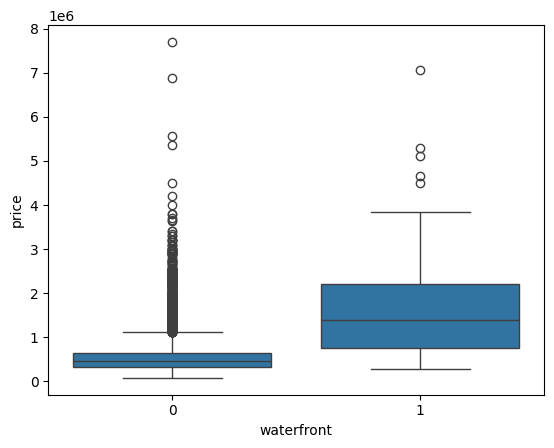

In [ ]:
sns.boxplot(x='waterfront', y='price', data=df)
plt.show()

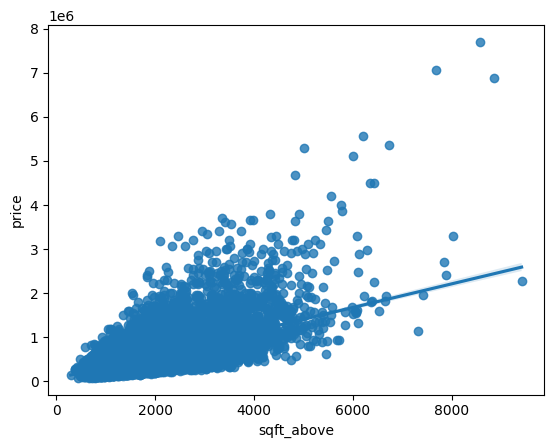

In [ ]:
sns.regplot(x='sqft_above', y='price', data=df)
plt.show()

In [ ]:
lm = LinearRegression()
X_single = df[['sqft_living']]
Y = df['price']
lm.fit(X_single, Y)
print("R^2 (sqft_living):", lm.score(X_single, Y))

R^2 (sqft_living): 0.4928532179037931


In [ ]:
lm_multi = LinearRegression()
Z = df[features] # features đã được khai báo ở phần chuẩn bị
lm_multi.fit(Z, Y)
print("R^2 (Multiple Features):", lm_multi.score(Z, Y))

R^2 (Multiple Features): 0.65769516660375


In [ ]:
Input = [('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe = Pipeline(Input)
pipe.fit(Z, Y)
print("R^2 (Pipeline):", pipe.score(Z, Y))

R^2 (Pipeline): 0.7513408515988734


In [ ]:
RidgeModel = Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train) # x_train, y_train đã tạo ở phần chuẩn bị
print("R^2 (Ridge on Test Data):", RidgeModel.score(x_test, y_test))

R^2 (Ridge on Test Data): 0.6478759163939113


In [ ]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.fit_transform(x_test)

RidgeModel_poly = Ridge(alpha=0.1)
RidgeModel_poly.fit(x_train_pr, y_train)
print("R^2 (Poly Ridge on Test Data):", RidgeModel_poly.score(x_test_pr, y_test))

R^2 (Poly Ridge on Test Data): 0.7002744273539743
